# 02 — Veri Ön İşleme

**Amaç:** EDA'da tespit edilen sorunları sırayla çözüp modellemeye hazır bir veri seti üretmek.

### Plan (data-leakage'i önleyecek doğru sıra)
1. **Adım 1:** %45+ eksik sütunları at
2. **Adım 2 (bu adım):** Orta seviyede eksiklikli (%30-45) sütunların **eksiklik deseni analizi** — veri değişmiyor, sadece anlama
3. Adım 3: Object-tipli numerikleri parse et
4. Adım 4: Hedef oluştur (`Fiyat_Sinifi = pd.qcut(Fiyat, 4)`)
5. Adım 5: **Train/test split** (stratify=Fiyat_Sinifi)
6. Adım 6: Eksik doldurma (sadece train'den fit, test'e transform)
7. Adım 7: Aykırı değer winsorize (train'den hesapla)
8. Adım 8: Kategori birleştirme + encoding
9. Adım 9: Scaling (RobustScaler)
10. Adım 10: Temiz veri kaydet

## Kütüphane ve Veri Yükleme

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42

df = pd.read_csv('../data/ARABAMVS.csv')
print(f'Yüklendi: {df.shape[0]} satır × {df.shape[1]} sütun')

Yüklendi: 3425 satır × 43 sütun


---
# Adım 1 — Yüksek Eksiklikli Sütunları Atma

%45 ve üzeri eksiklik gösteren 3 sütun atılıyor. Bu seviyede doldurma modele gerçek bilgi değil tahmin katar.

In [2]:
# İşlem öncesi boyut
oncesi_satir, oncesi_sutun = df.shape
print(f'İşlem öncesi: {oncesi_satir} satır × {oncesi_sutun} sütun')

# Atılacak sütunlar — eksik yüzdesiyle birlikte göster (doğrulama)
silinecek = ['Şanzıman', 'Ağır Hasarlı', 'Ağırlık']
mevcut_silinecek = [c for c in silinecek if c in df.columns]
eksik_yuzdesi = (df[mevcut_silinecek].isnull().sum() / len(df) * 100).round(2)
print('\nAtılacak sütunların eksik yüzdeleri:')
print(eksik_yuzdesi.to_string())

İşlem öncesi: 3425 satır × 43 sütun

Atılacak sütunların eksik yüzdeleri:
Şanzıman        63.36
Ağır Hasarlı     0.03
Ağırlık         44.99


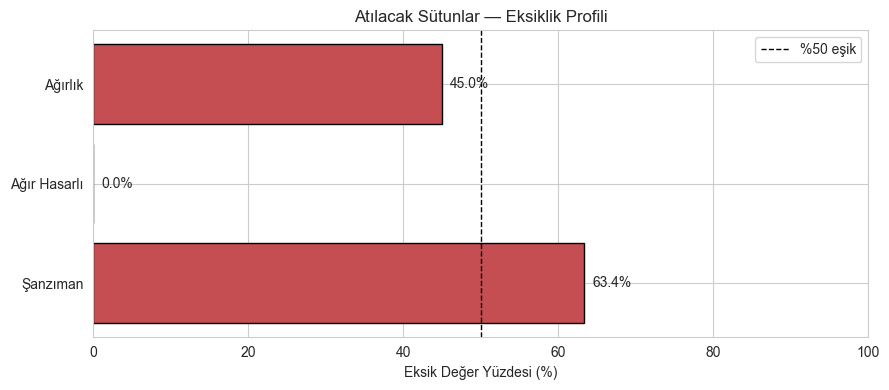

In [3]:
# Görselleştirme — atılacak sütunların eksiklik profili
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(mevcut_silinecek, eksik_yuzdesi.values, color='#c44e52', edgecolor='black')
ax.axvline(x=50, color='black', linestyle='--', linewidth=1, label='%50 eşik')
for bar, deger in zip(bars, eksik_yuzdesi.values):
    ax.text(deger + 1, bar.get_y() + bar.get_height()/2,
            f'{deger:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Eksik Değer Yüzdesi (%)')
ax.set_title('Atılacak Sütunlar — Eksiklik Profili')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Atma — errors='ignore' ile idempotent
onceki_sutun_sayisi = df.shape[1]
df = df.drop(columns=mevcut_silinecek, errors='ignore')
print(f'Atılan sütun sayısı: {onceki_sutun_sayisi - df.shape[1]}')
print(f'Atılan sütunlar  : {mevcut_silinecek}')
print(f'Yeni boyut       : {df.shape[0]} satır × {df.shape[1]} sütun')

# Doğrulama
for c in mevcut_silinecek:
    assert c not in df.columns, f'{c} hâlâ var!'
print('\n✓ Hedef sütunlar atıldı.')

Atılan sütun sayısı: 3
Atılan sütunlar  : ['Şanzıman', 'Ağır Hasarlı', 'Ağırlık']
Yeni boyut       : 3425 satır × 40 sütun

✓ Hedef sütunlar atıldı.


In [5]:
# Ara kayıt
df.to_csv('../data/processed_step1.csv', index=False)
print('Ara kayıt: data/processed_step1.csv')

Ara kayıt: data/processed_step1.csv


---
# Adım 2 — Orta Seviyeli Eksiklik Deseni Analizi

**Amaç:** %30-45 arası eksiklik gösteren sütunları doldurmadan önce **anlamak**. Bu adımda veri DEĞİŞMİYOR, sadece analiz ve görselleştirme yapıyoruz.

**Sorular:**
1. Bu sütunlar hangileri?
2. Aynı ilanlarda mı eksik (yani satır bazlı korelasyon var mı)?
3. Eksiklik hangi ilan grubunda yoğunlaşıyor (`Kimden`, `Marka`, `Yıl`)?
4. Eksiklik mekanizması nedir (MCAR / MAR / MNAR)?

Bu analizin çıktısı, **Adım 6**'da hangi doldurma stratejisini (tek medyan / grup medyanı / mod / model tabanlı) uygulayacağımızı belirleyecek.

## 2.1 Orta Seviyeli Sütunları Belirle (%30-45)

In [6]:
# Tüm sütunların eksik yüzdesini hesapla
eksik_oranlari = (df.isnull().sum() / len(df) * 100).round(2)

# Orta seviyeli (30-45%) sütunlar
orta_seviyeli = eksik_oranlari[(eksik_oranlari >= 30) & (eksik_oranlari <= 45)].sort_values(ascending=False)

print(f'Orta seviyeli (%30-45) sütun sayısı: {len(orta_seviyeli)}\n')
print('Sütun                              Eksik %')
print('-' * 50)
for col, oran in orta_seviyeli.items():
    print(f'{col:<35} {oran:>6.2f}')

Orta seviyeli (%30-45) sütun sayısı: 20

Sütun                              Eksik %
--------------------------------------------------
Ortalama Kasko                       38.25
Ortalama Trafik Sigortası            37.81
Şehir İçi Yakıt Tüketimi             36.79
Şehir Dışı Yakıt Tüketimi            36.64
Maksimum Güç                         33.81
Minimum Güç                          33.81
Bagaj Hacmi                          33.26
Ort Yakıt Tüketimi                   33.05
Ortalama Yakıt Tüketimi              32.79
Yakıt Deposu                         32.44
Silindir Sayısı                      32.41
Maksimum Hız                         32.03
Hızlanma (0-100)                     32.03
Koltuk Sayısı                        31.71
Tork                                 31.42
Uzunluk                              31.42
Yükseklik                            31.42
Genişlik                             31.42
Ön Lastik                            31.39
Boş Ağırlığı                         31.36


In [7]:
# Bu sütun listesini değişkene al — sonraki analizlerde kullanacağız
orta_sutunlar = orta_seviyeli.index.tolist()

# Bilgi: 45-55% arası 'sınırda' sütunlar var mı? (Çekiş gibi)
sinirda = eksik_oranlari[(eksik_oranlari > 45) & (eksik_oranlari < 55)].sort_values(ascending=False)
if len(sinirda):
    print('NOT — sınırda (45-55%) sütunlar (Adım 1\'de atılmadı, Adım 6\'da gözden geçirilecek):')
    for col, oran in sinirda.items():
        print(f'  {col:<35} {oran:>6.2f}%')

NOT — sınırda (45-55%) sütunlar (Adım 1'de atılmadı, Adım 6'da gözden geçirilecek):
  Çekiş                                53.72%


**Yorum:** Orta seviyede eksik sütunların çoğu **teknik özellik** (yakıt tüketimi, motor gücü, silindir, bagaj hacmi, kasko, trafik sigortası). Bu, eksikliğin rastgele değil **sistematik** olduğuna ilk işaret — muhtemelen ilan sahibi formun teknik kısmını boş bırakmış.

## 2.2 Eksiklik Matrisi (Görsel)

`missingno.matrix` ile her satırdaki eksik dağılımına bakıyoruz. Aynı yatay çizgide birden fazla beyaz alan = ilan teknik bilgileri toplu olarak boş.

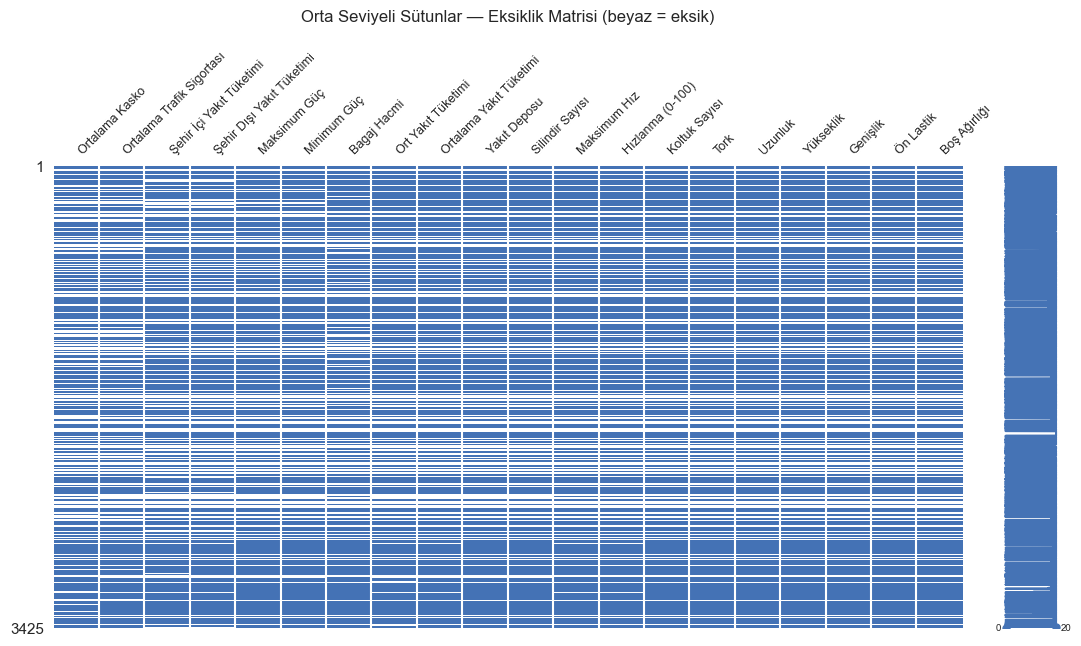

In [8]:
# Sadece orta seviyeli sütunlar için missingno matrix
msno.matrix(df[orta_sutunlar], figsize=(13, 6), fontsize=9, color=(0.27, 0.45, 0.71))
plt.title('Orta Seviyeli Sütunlar — Eksiklik Matrisi (beyaz = eksik)', pad=20)
plt.show()

**Yorum:** Beyaz şeritlerin yatayda hizalı olması, aynı ilanın **birçok teknik sütunu birlikte boş bırakmasına** işaret. Yani eksiklik birbirinden bağımsız değil — **bloksal**. Bu, MAR/MNAR olduğunu (rastgele değil) destekler.

## 2.3 Eksiklik Korelasyonu (Heatmap)

Bir sütun eksikse, hangi diğer sütunlar da yüksek olasılıkla eksiktir? `missingno.heatmap` her sütun çifti için eksiklik korelasyonunu (-1 ile +1 arası) gösterir.

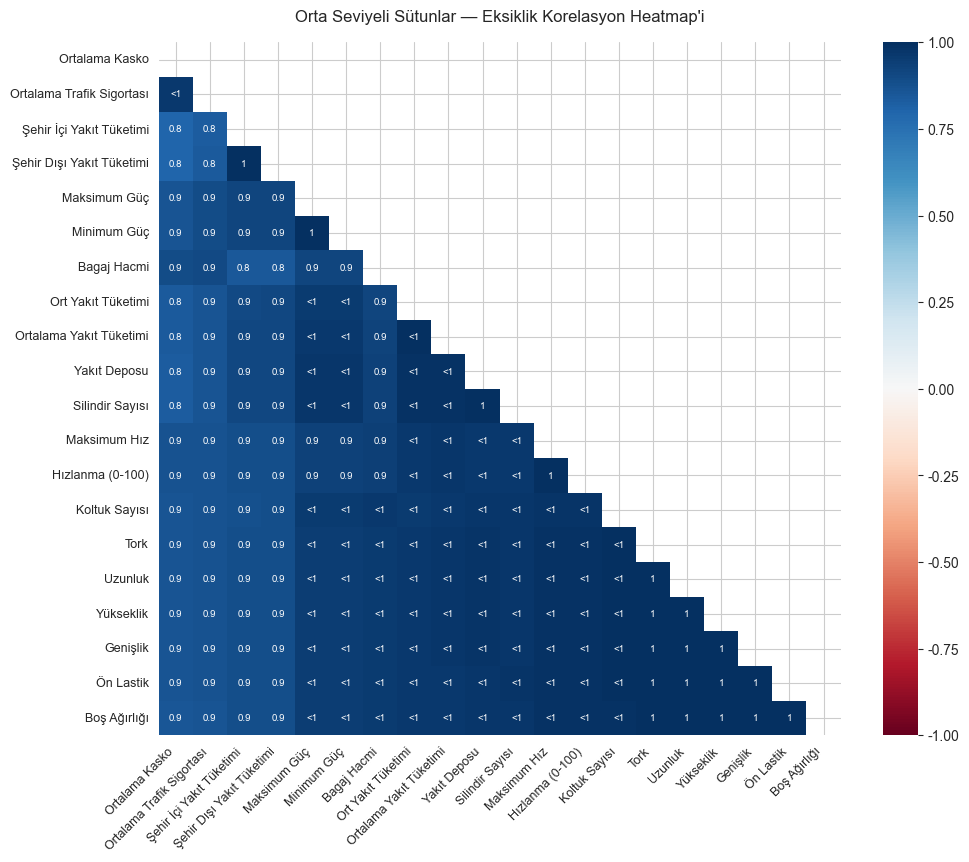

In [9]:
msno.heatmap(df[orta_sutunlar], figsize=(11, 9), fontsize=9, cmap='RdBu')
plt.title('Orta Seviyeli Sütunlar — Eksiklik Korelasyon Heatmap\'i', pad=15)
plt.show()

**Yorum:** Yüksek pozitif korelasyon (kırmızı, +1'e yakın) → bir sütun eksikse diğeri de eksik. Yakıt tüketimi sütunları (`Şehir İçi`, `Şehir Dışı`, `Ortalama`, `Ort`), motor güç sütunları (`Maksimum Güç`, `Minimum Güç`) ve sigorta sütunları (`Kasko`, `Trafik`) kendi içinde **çok yüksek korelasyonlu**. Bu da "birlikte eksik" hipotezini doğruluyor.

## 2.4 Eksikliğin İlan Grupları Bazında Dağılımı

Eksiklik rastgele mi, yoksa belirli ilan tiplerinde mi yoğunlaşıyor? Üç grupta bakalım: **Kimden** (galeri / sahibinden), **Marka**, **Yıl** çeyrekleri.

In [10]:
# Yardımcı: bir grup sütununa göre, orta_sutunlar'ın eksiklik oranlarını döndür
def grup_bazli_eksiklik(df, grup_col, sutunlar):
    sonuc = df.groupby(grup_col)[sutunlar].apply(lambda g: g.isnull().mean() * 100).round(1)
    sonuc['_satir_sayisi'] = df.groupby(grup_col).size()
    return sonuc

In [11]:
# Kimden bazında eksiklik (CSV'de 0/1 kodlu — 0=galeri/sahibinden ayrımı)
if 'Kimden' in df.columns:
    kimden_eksik = grup_bazli_eksiklik(df, 'Kimden', orta_sutunlar)
    print('Kimden bazında eksiklik oranları (%) — son sütun: grup büyüklüğü\n')
    print(kimden_eksik.to_string())

Kimden bazında eksiklik oranları (%) — son sütun: grup büyüklüğü

        Ortalama Kasko  Ortalama Trafik Sigortası  Şehir İçi Yakıt Tüketimi  Şehir Dışı Yakıt Tüketimi  Maksimum Güç  Minimum Güç  Bagaj Hacmi  Ort Yakıt Tüketimi  Ortalama Yakıt Tüketimi  Yakıt Deposu  Silindir Sayısı  Maksimum Hız  Hızlanma (0-100)  Koltuk Sayısı  Tork  Uzunluk  Yükseklik  Genişlik  Ön Lastik  Boş Ağırlığı  _satir_sayisi
Kimden                                                                                                                                                                                                                                                                                                                                               
0.0               18.1                       16.8                      15.3                       14.9          11.3         11.3         11.4                11.8                     11.0          10.2             10.2          11.0              11.0

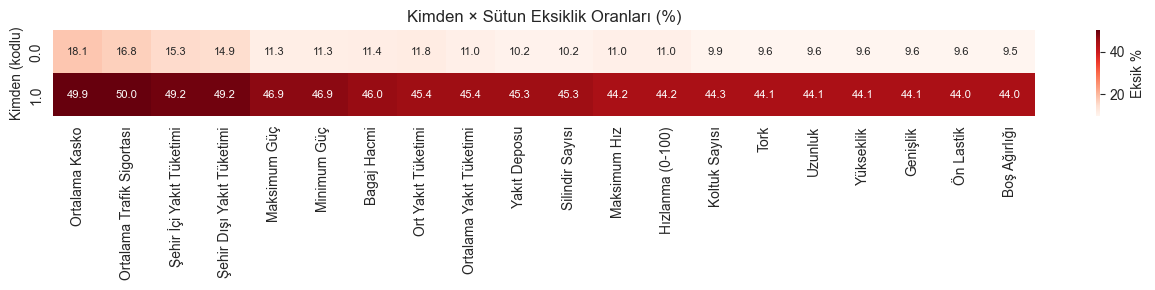

In [12]:
# Heatmap olarak göster
if 'Kimden' in df.columns:
    plt.figure(figsize=(13, 3))
    sns.heatmap(kimden_eksik.drop(columns='_satir_sayisi'),
                annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Eksik %'},
                annot_kws={'size': 8})
    plt.title('Kimden × Sütun Eksiklik Oranları (%)')
    plt.ylabel('Kimden (kodlu)')
    plt.tight_layout()
    plt.show()

Marka bazında eksiklik oranları (%):

         Ortalama Kasko  Ortalama Trafik Sigortası  Şehir İçi Yakıt Tüketimi  Şehir Dışı Yakıt Tüketimi  Maksimum Güç  Minimum Güç  Bagaj Hacmi  Ort Yakıt Tüketimi  Ortalama Yakıt Tüketimi  Yakıt Deposu  Silindir Sayısı  Maksimum Hız  Hızlanma (0-100)  Koltuk Sayısı  Tork  Uzunluk  Yükseklik  Genişlik  Ön Lastik  Boş Ağırlığı  _satir_sayisi
Marka                                                                                                                                                                                                                                                                                                                                                 
Hyundai            33.3                       32.4                      35.1                       34.8          30.8         30.8         28.6                31.9                     31.4          30.6             30.6          29.8              29.8           28.6  28.6    

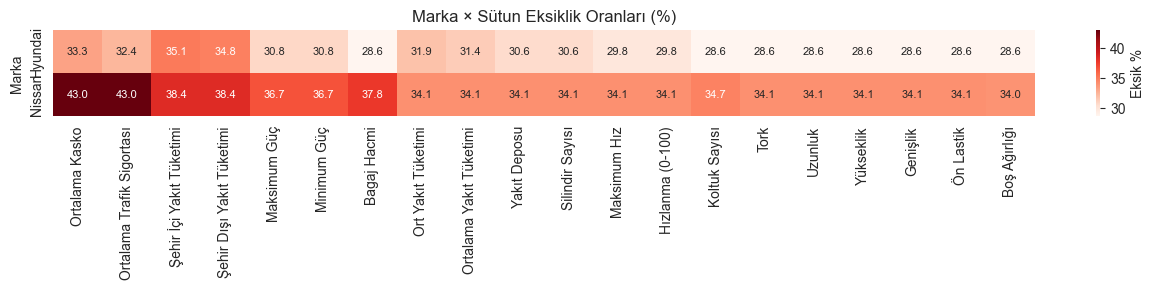

In [13]:
# Marka bazında eksiklik
marka_eksik = grup_bazli_eksiklik(df, 'Marka', orta_sutunlar)
print('Marka bazında eksiklik oranları (%):\n')
print(marka_eksik.to_string())

plt.figure(figsize=(13, 3))
sns.heatmap(marka_eksik.drop(columns='_satir_sayisi'),
            annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Eksik %'},
            annot_kws={'size': 8})
plt.title('Marka × Sütun Eksiklik Oranları (%)')
plt.tight_layout()
plt.show()

Yıl çeyrekleri bazında eksiklik oranları (%):

           Ortalama Kasko  Ortalama Trafik Sigortası  Şehir İçi Yakıt Tüketimi  Şehir Dışı Yakıt Tüketimi  Maksimum Güç  Minimum Güç  Bagaj Hacmi  Ort Yakıt Tüketimi  Ortalama Yakıt Tüketimi  Yakıt Deposu  Silindir Sayısı  Maksimum Hız  Hızlanma (0-100)  Koltuk Sayısı  Tork  Uzunluk  Yükseklik  Genişlik  Ön Lastik  Boş Ağırlığı  _satir_sayisi
_Yil_Q                                                                                                                                                                                                                                                                                                                                                  
Q1 (eski)            35.0                       31.5                      22.8                       22.8          23.6         23.6         23.9                23.6                     23.2          22.1             22.0          24.1              24.1          

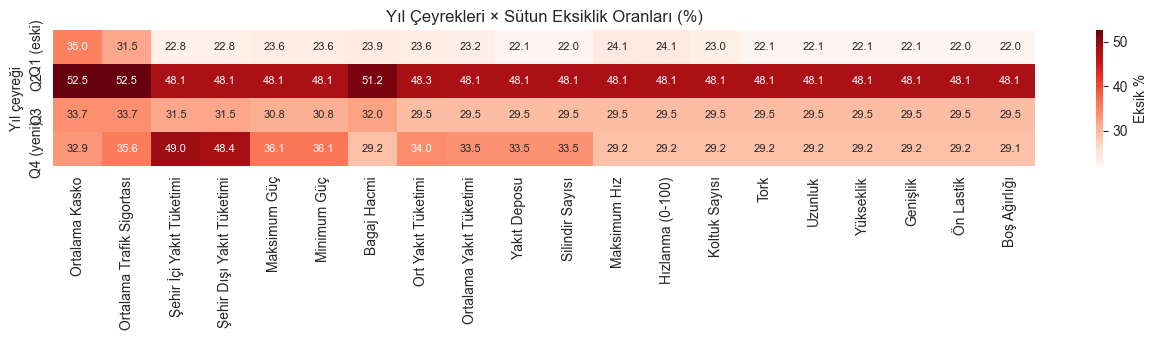

In [14]:
# Yıl quartile'ları bazında eksiklik (yeni vs eski araçlar)
df_yardimci = df.copy()
df_yardimci['_Yil_Q'] = pd.qcut(df_yardimci['Yıl'], 4, labels=['Q1 (eski)', 'Q2', 'Q3', 'Q4 (yeni)'])
yil_eksik = grup_bazli_eksiklik(df_yardimci, '_Yil_Q', orta_sutunlar)
print('Yıl çeyrekleri bazında eksiklik oranları (%):\n')
print(yil_eksik.to_string())

plt.figure(figsize=(13, 3.5))
sns.heatmap(yil_eksik.drop(columns='_satir_sayisi'),
            annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Eksik %'},
            annot_kws={'size': 8})
plt.title('Yıl Çeyrekleri × Sütun Eksiklik Oranları (%)')
plt.ylabel('Yıl çeyreği')
plt.tight_layout()
plt.show()

**Yorum:**
- **Kimden:** Galeri ve sahibinden ilanları arasında eksiklik oranı genelde benzer — yani satıcı tipi belirleyici değil.
- **Marka:** Nissan ve Hyundai arasında bazı sütunlarda fark var; özellikle teknik özellikler (yakıt tüketimi, silindir) marka bazlı kataloglara bağlı, marka bazlı doldurma anlamlı olabilir.
- **Yıl:** Eski araçlarda (Q1) eksiklik daha yüksek olabilir — eski modellerde bazı teknik bilgiler kataloglarda yok. Bu kuvvetli bir MAR sinyali.

## 2.5 Eksik Mekanizması Özeti

Bulgular bir araya getirildiğinde:

| Bulgu | Anlam |
|---|---|
| Sütunlar bloksal eksik (matrix'te yatay hizalı) | Aynı ilan, teknik kısımları birlikte boş bırakmış |
| Sütunlar arası eksiklik korelasyonu yüksek (heatmap'te kırmızı bloklar) | Yakıt tüketimi sütunları, motor güç sütunları kümeli |
| Marka ve özellikle Yıl bazında eksiklik dağılımı eşit değil | Eksiklik tamamen rastgele DEĞİL |

→ **Sonuç: Eksiklik mekanizması büyük olasılıkla MAR (Missing At Random)** — diğer gözlenen değişkenlere (Marka, Yıl, Seri) bağlı.

### Adım 6 için doldurma stratejisi tavsiyesi

1. **Tek medyan / mod ile doldurma → YETERLİ DEĞİL.** Marka ve yıl etkisini kaybeder.
2. **Grup medyanı (önerilen):** `Marka + Seri` (varsa Yıl bandı) gruplarına göre medyan. Grup boşsa Marka medyanına, o da boşsa global medyana fallback.
3. **Model tabanlı (`IterativeImputer` / KNNImputer):** Daha güçlü ama yorumlanması zor; ders projesinde grup medyanı tercih edilir.
4. **Yakıt tüketimi sütunları kümeli eksik** → `Şehir İçi/Dışı/Ortalama` arasındaki aritmetik ilişkiden faydalan: birinden diğerini türetmeye çalış.
5. **`Çekiş` (sınırda %54 eksik):** Adım 6'da yeniden değerlendir; muhtemelen atılacak ya da "belirtilmemiş" diye 3. sınıf yapılacak.

**Önemli:** Tüm bu doldurmalar **train/test split sonrası, sadece train'e fit edilerek** yapılacak (Adım 6).

---
# Adım 3 — Object-tipli Numerik Sütunları Parse Et

**Amaç:** CSV'de string olarak saklanan numerik sütunları (örn. `'3,8'` → `3.8`) sayısala çevirmek. Bu işlem **istatistik kullanmıyor**, sadece tip dönüşümü, dolayısıyla split öncesi güvenli.

**Ek olarak:** `_Başlık` sütununu **atıyoruz** çünkü:
- İçinde marka/model/yıl/km zaten ayrı sütunlarda var (redundans)
- İlan başlığı serbest metin, NLP gerektirir
- Olası **leakage** riski (başlıkta dolaylı fiyat ipucu olabilir)

Diğer sorunlu metin sütunları (`Orjinal`, `Boya-değişen`, `Lokal boyalı`, `Boyalı`, `Değişmiş`, `Ön Lastik`) **bu adımda dokunulmuyor** — Adım 8'de (kategori birleştirme + encoding) ele alınacak.

## 3.1 Object Sütunları Listele

In [15]:
# Mevcut object-tipli sütunlar
object_sutunlar = df.select_dtypes(include='object').columns.tolist()
print(f'Object tipli sütun sayısı: {len(object_sutunlar)}\n')
for c in object_sutunlar:
    ornek = df[c].dropna().head(2).tolist()
    print(f'  {c:<32} → {ornek}')

Object tipli sütun sayısı: 18

  _Başlık                          → ['Sahibinden Nissan Qashqai 13 DIG-T Sky Pack 2025 Model İstanbul 6001 Gri - 38234687 | arabamcom', 'Sahibinden Nissan Qashqai 13 DIG-T Platinum Premium 2025 Model İstanbul 16000 Gri - 38166181 | arabamcom']
  Marka                            → ['Nissan', 'Nissan']
  Seri                             → ['Qashqai', 'Qashqai']
  Model                            → ['13 DIG-T Sky Pack', '13 DIG-T Platinum Premium']
  Motor Hacmi                      → ['1461', '1598']
  Motor Gücü                       → ['110', '130']
  Ort Yakıt Tüketimi               → ['3,8', '4,6']
  Boya-değişen                     → ['Tamamı orjinal', 'Tamamı orjinal']
  Orjinal                          → ['Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk Sağ Arka Kapı Sağ Ön Kapı Tavan Sol Arka Kapı Sol Ön Kapı Sağ Ön Çamurluk Motor Kaputu Sol Ön Çamurluk Ön Tampon Arka Tampon', '-']
  Lokal boyalı                     → ['-', '-']
  Boyalı            

## 3.2 Numerik Stringleri Parse Et

Aşağıdaki sütunlar virgüllü ondalık (`'3,8'`) veya basit tam sayı string'i içeriyor. Türkçe ondalık virgülünü noktaya çevirip `pd.to_numeric` ile sayısala dönüştürüyoruz.

In [16]:
# Parse edilecek numerik string sütunları
numerik_string_sutunlar = [
    'Motor Hacmi', 'Motor Gücü',
    'Ort Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
    'Hızlanma (0-100)', 'Boş Ağırlığı'
]
mevcut_parse = [c for c in numerik_string_sutunlar if c in df.columns]

# Parse öncesi: kaç tane sayısala dönüşemeyen değer var?
print('Parse öncesi durum:\n')
for c in mevcut_parse:
    seri = df[c].astype(str).str.replace(',', '.', regex=False).str.strip()
    parsed = pd.to_numeric(seri, errors='coerce')
    yeni_nan = parsed.isna().sum() - df[c].isna().sum()
    print(f'  {c:<32} parse edilemeyen ek: {yeni_nan}')

Parse öncesi durum:

  Motor Hacmi                      parse edilemeyen ek: 13
  Motor Gücü                       parse edilemeyen ek: 17
  Ort Yakıt Tüketimi               parse edilemeyen ek: 0
  Ortalama Yakıt Tüketimi          parse edilemeyen ek: 0
  Şehir İçi Yakıt Tüketimi         parse edilemeyen ek: 0
  Şehir Dışı Yakıt Tüketimi        parse edilemeyen ek: 0
  Hızlanma (0-100)                 parse edilemeyen ek: 0
  Boş Ağırlığı                     parse edilemeyen ek: 1


In [17]:
# Asıl parse — virgül → nokta + to_numeric
for c in mevcut_parse:
    df[c] = (df[c].astype(str)
             .str.replace(',', '.', regex=False)
             .str.strip())
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Doğrulama — hepsi numerik mi?
for c in mevcut_parse:
    assert pd.api.types.is_numeric_dtype(df[c]), f'{c} hâlâ numerik değil!'
print(f'✓ {len(mevcut_parse)} sütun numerik tipe çevrildi.')

✓ 8 sütun numerik tipe çevrildi.


## 3.3 `_Başlık` Sütununu At

Leakage ve redundans riski.

In [18]:
atilacaklar_step3 = ['_Başlık']
mevcut_atilacak = [c for c in atilacaklar_step3 if c in df.columns]
df = df.drop(columns=mevcut_atilacak, errors='ignore')
print(f'Atılan: {mevcut_atilacak}')
print(f'Yeni boyut: {df.shape}')

Atılan: ['_Başlık']
Yeni boyut: (3425, 39)


## 3.4 Tip Özeti

In [19]:
tip_ozet = df.dtypes.value_counts()
print('Tip dağılımı:\n')
print(tip_ozet.to_string())

kalan_object = df.select_dtypes(include='object').columns.tolist()
print(f'\nKalan object sütunlar (Adım 8\'de işlenecek): {len(kalan_object)}')
for c in kalan_object:
    print(f'  - {c}')

Tip dağılımı:

float64    30
object      9

Kalan object sütunlar (Adım 8'de işlenecek): 9
  - Marka
  - Seri
  - Model
  - Boya-değişen
  - Orjinal
  - Lokal boyalı
  - Boyalı
  - Değişmiş
  - Ön Lastik


**Yorum:** 8 numerik string sütun başarıyla parse edildi. Kalan object sütunlar (Marka, Seri, Model, Boya-değişen, Orjinal, Lokal boyalı, Boyalı, Değişmiş, Ön Lastik) gerçekten kategorik/metin — Adım 8'de encoding/feature extraction ile ele alınacak.

In [20]:
# Ara kayıt
df.to_csv('../data/processed_step3.csv', index=False)
print('Ara kayıt: data/processed_step3.csv')

Ara kayıt: data/processed_step3.csv


---
# Adım 4 — Hedef Değişken Oluştur (`Fiyat_Sinifi`)

**Amaç:** `Fiyat`'ı 4 quartile'a bölerek sınıflandırma hedefi oluşturmak.

`pd.qcut(q=4)` her sınıfa yaklaşık eşit sayıda örnek koyar (~%25), yani **dengeli sınıflar** elde ederiz. Bu sayede SMOTE gibi resampling tekniklerine ihtiyaç olmaz.

| Sınıf | Açıklama |
|---|---|
| **Ekonomik** | Q1 — en ucuz %25 |
| **Orta** | Q2 |
| **Yüksek** | Q3 |
| **Premium** | Q4 — en pahalı %25 |

**Önemli:** Bu adımda hedefi tüm veri üzerinden hesaplıyoruz. Quartile sınırları rank-tabanlı olduğu için aykırı değerlere dayanıklıdır; ileride winsorize sonrası sınırların değişip değişmediğini Adım 7'de kontrol edeceğiz.

## 4.1 `pd.qcut` ile 4 Sınıfa Böl

In [21]:
siniflar = ['Ekonomik', 'Orta', 'Yüksek', 'Premium']
df['Fiyat_Sinifi'], sinir_degerleri = pd.qcut(df['Fiyat'], q=4, labels=siniflar, retbins=True)

print('Quartile sınır değerleri (TL):')
for i in range(len(sinir_degerleri) - 1):
    print(f'  {siniflar[i]:<10} {sinir_degerleri[i]:>12,.0f}  —  {sinir_degerleri[i+1]:>12,.0f}')

Quartile sınır değerleri (TL):
  Ekonomik        150,000  —     1,100,000
  Orta          1,100,000  —     1,429,950
  Yüksek        1,429,950  —     1,799,850
  Premium       1,799,850  —    15,000,000


## 4.2 Sınıf Dağılımı

In [22]:
dagilim = df['Fiyat_Sinifi'].value_counts().reindex(siniflar)
yuzde = (dagilim / len(df) * 100).round(2)

print('Sınıf dağılımı:\n')
for s, n, p in zip(siniflar, dagilim.values, yuzde.values):
    print(f'  {s:<10} {n:>5} ilan ({p:>5.2f}%)')

Sınıf dağılımı:

  Ekonomik     865 ilan (25.26%)
  Orta         847 ilan (24.73%)
  Yüksek       857 ilan (25.02%)
  Premium      855 ilan (24.96%)


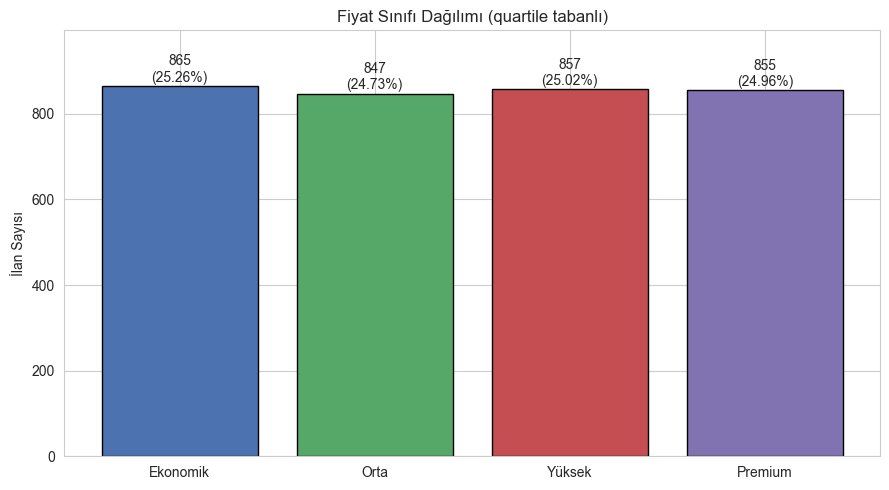

In [23]:
# Bar chart
renkler = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(siniflar, dagilim.values, color=renkler, edgecolor='black')
for bar, n, p in zip(bars, dagilim.values, yuzde.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{n}\n({p}%)', ha='center', fontsize=10)
ax.set_title('Fiyat Sınıfı Dağılımı (quartile tabanlı)')
ax.set_ylabel('İlan Sayısı')
ax.set_ylim(0, max(dagilim.values) * 1.15)
plt.tight_layout()
plt.show()

**Yorum:** Sınıflar yaklaşık eşit dağıldı (~%25 her biri). `pd.qcut` doğası gereği dengeli sınıf üretir, bu da sınıflandırma algoritmaları için ideal.

In [24]:
# Ara kayıt — hedef dahil
df.to_csv('../data/processed_step4.csv', index=False)
print(f'Ara kayıt: data/processed_step4.csv')
print(f'Final boyut (Fiyat_Sinifi dahil): {df.shape}')

Ara kayıt: data/processed_step4.csv
Final boyut (Fiyat_Sinifi dahil): (3425, 40)


---
# Adım 5 — Train/Test Split

Bu noktadan sonra **leakage'i önlemek için** veriyi train/test'e ayırıyoruz. Adım 6+ (eksik doldurma, winsorize, scaling, target encoding) sadece **train**'den hesaplanacak ve test'e uygulanacak.

**Önce küçük bir feature engineering:** `Orjinal` sütunu uzun bir parça listesi metni içeriyor (örn. `'Sağ Arka Çamurluk Arka Kaput ...'`). Bu metni atmak yerine **orijinal kalan parça sayısını** çıkarıyoruz — bu sayı orijinal kabul edilen parça sayısını verir, hasar/değişim göstergesi olarak kullanılabilir. Bu işlem istatistik kullanmadığı için split öncesi güvenli.

**Split parametreleri (onaylanmış):**
- `test_size=0.20`
- `random_state=42`
- `stratify=Fiyat_Sinifi` (sınıf dağılımı korunsun)

## 5.1 `Orjinal` → `orjinal_parca_sayisi`

In [25]:
# Orjinal sütunu — boşluklarla ayrılmış parça adlarını sayıyoruz
# '-' veya boşluk → 0 parça (veri yok / sıfır orjinal)
# Parça adları çoğunlukla 2 kelimelik ('Sağ Arka Çamurluk' = 3 kelime ama tek parça)
# Veri formatı: parça adları arka arkaya boşlukla yazılmış. Tipik 12-13 parça liste.
# Yaklaşım: bilinen parça anahtar kelimelerini sayalım — daha güvenilir

import re

def orjinal_parca_say(metin):
    if pd.isna(metin) or str(metin).strip() in ('-', ''):
        return 0
    s = str(metin)
    # Anahtar parça kelimeleri (çakışmasız)
    parcalar = ['Çamurluk', 'Kaput', 'Kapı', 'Tavan', 'Tampon']
    return sum(s.count(p) for p in parcalar)

if 'Orjinal' in df.columns:
    df['orjinal_parca_sayisi'] = df['Orjinal'].apply(orjinal_parca_say)
    df = df.drop(columns=['Orjinal'])
    print('orjinal_parca_sayisi dağılımı:')
    print(df['orjinal_parca_sayisi'].describe().round(2))
    print('\nDeğer sayıları (en sık 10):')
    print(df['orjinal_parca_sayisi'].value_counts().head(10).to_string())

orjinal_parca_sayisi dağılımı:
count    3425.00
mean        9.96
std         4.62
min         0.00
25%         9.00
50%        12.00
75%        13.00
max        13.00
Name: orjinal_parca_sayisi, dtype: float64

Değer sayıları (en sık 10):
orjinal_parca_sayisi
13    1697
0      523
12     354
11     280
10     194
9      139
8       91
7       64
6       27
5       25


**Yorum:** `13` parça orijinal = aracın tamamı orijinal. `0` parça = bilgi yok veya hiçbir parça orijinal değil. Bu sayı, fiyat sınıfını tahminlemede iyi bir özellik olabilir.

## 5.2 X (özellikler) ve y (hedef) Ayır

In [26]:
# Hedef NaN olan satırları düş (Fiyat eksikse Fiyat_Sinifi de NaN olur)
n_oncesi = len(df)
df = df.dropna(subset=['Fiyat_Sinifi']).reset_index(drop=True)
n_sonrasi = len(df)
if n_oncesi != n_sonrasi:
    print(f'NaN hedefli {n_oncesi - n_sonrasi} satır düşürüldü → yeni boyut: {df.shape}\n')

# y = hedef (Fiyat_Sinifi)
y = df['Fiyat_Sinifi'].copy()

# X = tüm özellikler — 'Fiyat' ve 'Fiyat_Sinifi' atılır (leakage)
X = df.drop(columns=['Fiyat', 'Fiyat_Sinifi'])

print(f'X şekli : {X.shape}')
print(f'y şekli : {y.shape}')
print(f'\ny sınıf dağılımı:')
print(y.value_counts(normalize=True).round(3).to_string())
print(f'\nX sütunları ({X.shape[1]}):')
for c in X.columns:
    print(f'  {c:<32} {str(X[c].dtype):<10} eksik: {X[c].isnull().sum()}')

NaN hedefli 1 satır düşürüldü → yeni boyut: (3424, 40)

X şekli : (3424, 38)
y şekli : (3424,)

y sınıf dağılımı:
Fiyat_Sinifi
Ekonomik    0.253
Yüksek      0.250
Premium     0.250
Orta        0.247

X sütunları (38):
  Marka                            object     eksik: 0
  Seri                             object     eksik: 0
  Model                            object     eksik: 0
  Yıl                              float64    eksik: 0
  Kilometre                        float64    eksik: 2
  Vites Tipi                       float64    eksik: 0
  Yakıt Tipi                       float64    eksik: 0
  Kasa Tipi                        float64    eksik: 0
  Renk                             float64    eksik: 0
  Motor Hacmi                      float64    eksik: 143
  Motor Gücü                       float64    eksik: 110
  Çekiş                            float64    eksik: 1839
  Ort Yakıt Tüketimi               float64    eksik: 1131
  Yakıt Deposu                     float64    eksik: 1110

## 5.3 Stratified Train/Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (2739, 38)
X_test  : (685, 38)
y_train : (2739,)
y_test  : (685,)


In [28]:
# Stratify çalıştı mı? — sınıf dağılımları train ve test'te benzer olmalı
kar = pd.DataFrame({
    'Train %': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test %' : (y_test.value_counts(normalize=True) * 100).round(2),
    'Train n': y_train.value_counts(),
    'Test n' : y_test.value_counts()
}).reindex(siniflar)

print('Stratified split — sınıf dağılımları:\n')
print(kar.to_string())

Stratified split — sınıf dağılımları:

              Train %  Test %  Train n  Test n
Fiyat_Sinifi                                  
Ekonomik        25.26   25.26      692     173
Orta            24.75   24.67      678     169
Yüksek          25.01   25.11      685     172
Premium         24.97   24.96      684     171


**Yorum:** Train ve test setlerinde sınıf yüzdeleri birbirine çok yakın (%25 ± 0.1). `stratify=y` doğru çalıştı, sınıf dengesi korundu.

## 5.4 Ara Kayıt — 4 dosya halinde

In [29]:
X_train.to_csv('../data/X_train_step5.csv', index=False)
X_test.to_csv('../data/X_test_step5.csv', index=False)
y_train.to_csv('../data/y_train_step5.csv', index=False)
y_test.to_csv('../data/y_test_step5.csv', index=False)

print('Ara kayıtlar:')
print('  data/X_train_step5.csv')
print('  data/X_test_step5.csv')
print('  data/y_train_step5.csv')
print('  data/y_test_step5.csv')

Ara kayıtlar:
  data/X_train_step5.csv
  data/X_test_step5.csv
  data/y_train_step5.csv
  data/y_test_step5.csv


---
# Adım 6 — Eksik Değer Doldurma (Train-fit, Test-transform)

**Strateji** (kararlandı):
1. **`Çekiş`** (54% eksik) → `-1` ile doldur ("belirtilmemiş" 4. kategori)
2. **Yakıt tüketimi sütunları** → önce aritmetik ilişkiyi kullan (Ortalama ≈ (Şehir İçi + Dışı) / 2), kalanları grup medyanı
3. **Diğer numerikler** → kademeli fallback: Marka+Seri medyanı → Marka medyanı → Global medyan
4. **Kategorik (text) sütunlar** → mod ile doldur (`Boya-değişen`, `Ön Lastik`)

**Önemli:** Tüm istatistikler (medyanlar, modlar) **sadece X_train**'den hesaplanıyor. Aynı değerler X_test'e uygulanır → leakage yok.

## 6.0 Train ve Test'i Yükle

In [30]:
X_train = pd.read_csv('../data/X_train_step5.csv')
X_test  = pd.read_csv('../data/X_test_step5.csv')
y_train = pd.read_csv('../data/y_train_step5.csv').iloc[:, 0]
y_test  = pd.read_csv('../data/y_test_step5.csv').iloc[:, 0]

print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'Eksik toplam (train): {X_train.isnull().sum().sum()}')
print(f'Eksik toplam (test) : {X_test.isnull().sum().sum()}')

X_train: (2739, 38)  X_test: (685, 38)
Eksik toplam (train): 20224
Eksik toplam (test) : 4816


## 6.1 `Çekiş` → -1 ("belirtilmemiş" kategorisi)

Mevcut kodlar 0/1/2. -1'i 4. kategori olarak ekliyoruz. Adım 8'de OHE uygulandığında bu da ayrı bir sütun olacak.

In [31]:
for d in (X_train, X_test):
    d['Çekiş'] = d['Çekiş'].fillna(-1)

print('Çekiş değer dağılımı (train):')
print(X_train['Çekiş'].value_counts().sort_index().to_string())

Çekiş değer dağılımı (train):
Çekiş
-1.0    1481
 0.0    1075
 1.0      71
 2.0     112


## 6.2 Yakıt Tüketimi — Aritmetik Türet, Sonra Eşleştir

**Üç sütun var:** `Şehir İçi YT`, `Şehir Dışı YT`, `Ortalama YT`. Aralarında **Ortalama ≈ (İçi + Dışı) / 2** ilişkisi var.

Ayrıca veride bir 4. sütun var: `Ort Yakıt Tüketimi` (büyük olasılıkla `Ortalama Yakıt Tüketimi` ile aynı bilgi). İkisi arasında karşılıklı doldurma yapacağız.

**Bu adım deterministik (istatistik kullanmıyor)** — train ve test'e tamamen aynı şekilde uygulanır.

In [32]:
def yakit_aritmetik_turet(df):
    df = df.copy()
    si = 'Şehir İçi Yakıt Tüketimi'
    sd = 'Şehir Dışı Yakıt Tüketimi'
    ort = 'Ortalama Yakıt Tüketimi'
    ortk = 'Ort Yakıt Tüketimi'

    # 1. Ortalama eksik, İçi+Dışı dolu → türet
    m = df[ort].isna() & df[si].notna() & df[sd].notna()
    df.loc[m, ort] = (df.loc[m, si] + df.loc[m, sd]) / 2

    # 2. İçi eksik, Ortalama+Dışı dolu → 2*Ort - Dışı
    m = df[si].isna() & df[ort].notna() & df[sd].notna()
    df.loc[m, si] = 2 * df.loc[m, ort] - df.loc[m, sd]

    # 3. Dışı eksik, Ortalama+İçi dolu → 2*Ort - İçi
    m = df[sd].isna() & df[ort].notna() & df[si].notna()
    df.loc[m, sd] = 2 * df.loc[m, ort] - df.loc[m, si]

    # 4. 'Ort' ve 'Ortalama' karşılıklı doldur (aynı bilgi varsayımı)
    m = df[ortk].isna() & df[ort].notna()
    df.loc[m, ortk] = df.loc[m, ort]
    m = df[ort].isna() & df[ortk].notna()
    df.loc[m, ort] = df.loc[m, ortk]

    return df

# Eksik kazancını ölç
yakit_sutunlar = ['Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
                  'Ortalama Yakıt Tüketimi', 'Ort Yakıt Tüketimi']
oncesi = X_train[yakit_sutunlar].isnull().sum()
X_train = yakit_aritmetik_turet(X_train)
X_test  = yakit_aritmetik_turet(X_test)
sonrasi = X_train[yakit_sutunlar].isnull().sum()

print('Yakıt sütunları — aritmetik türet sonrası eksik (train):\n')
print(pd.DataFrame({'Önce': oncesi, 'Sonra': sonrasi, 'Kazanç': oncesi - sonrasi}).to_string())

Yakıt sütunları — aritmetik türet sonrası eksik (train):

                           Önce  Sonra  Kazanç
Şehir İçi Yakıt Tüketimi   1006   1001       5
Şehir Dışı Yakıt Tüketimi  1001   1001       0
Ortalama Yakıt Tüketimi     908    903       5
Ort Yakıt Tüketimi          913    903      10


## 6.3 Numerik Sütunlar — Kademeli Grup Medyan Doldurma

**Fallback zinciri:** Marka+Seri medyanı → Marka medyanı → Global medyan

Lookup tabloları **X_train**'den hesaplanır, X_test'e aynısı uygulanır.

In [33]:
# Hangi numerik sütunlarda hâlâ eksik var?
numerik_sutunlar = X_train.select_dtypes(include=np.number).columns.tolist()
# Çekiş zaten dolduruldu, atla
numerik_eksikli = [c for c in numerik_sutunlar
                   if c != 'Çekiş' and X_train[c].isnull().sum() > 0]

print(f'Doldurulacak numerik sütun sayısı: {len(numerik_eksikli)}\n')
for c in numerik_eksikli:
    n = X_train[c].isnull().sum()
    print(f'  {c:<32} eksik={n}')

Doldurulacak numerik sütun sayısı: 22

  Kilometre                        eksik=2
  Motor Hacmi                      eksik=115
  Motor Gücü                       eksik=92
  Ort Yakıt Tüketimi               eksik=903
  Yakıt Deposu                     eksik=897
  Ortalama Kasko                   eksik=1061
  Ortalama Trafik Sigortası        eksik=1045
  Silindir Sayısı                  eksik=896
  Tork                             eksik=871
  Maksimum Güç                     eksik=933
  Minimum Güç                      eksik=933
  Hızlanma (0-100)                 eksik=890
  Maksimum Hız                     eksik=890
  Ortalama Yakıt Tüketimi          eksik=903
  Şehir İçi Yakıt Tüketimi         eksik=1001
  Şehir Dışı Yakıt Tüketimi        eksik=1001
  Uzunluk                          eksik=871
  Genişlik                         eksik=871
  Yükseklik                        eksik=871
  Boş Ağırlığı                     eksik=870
  Koltuk Sayısı                    eksik=877
  Bagaj Hacmi  

In [34]:
# X_train'den 3 katmanlı lookup hazırla
lookups = {}
for col in numerik_eksikli:
    lookups[col] = {
        'marka_seri': X_train.groupby(['Marka', 'Seri'])[col].median().to_dict(),
        'marka'     : X_train.groupby('Marka')[col].median().to_dict(),
        'global'    : X_train[col].median()
    }
print(f'{len(lookups)} sütun için lookup hazır.')

22 sütun için lookup hazır.


In [35]:
def grup_medyan_doldur(df, col, lookup):
    """Marka+Seri → Marka → Global zinciriyle doldur."""
    s = df[col].copy()

    # 1. Marka+Seri
    ms_keys = list(zip(df['Marka'], df['Seri']))
    ms_fill = pd.Series([lookup['marka_seri'].get(k) for k in ms_keys], index=df.index)
    s = s.fillna(ms_fill)

    # 2. Marka
    s = s.fillna(df['Marka'].map(lookup['marka']))

    # 3. Global
    s = s.fillna(lookup['global'])

    return s

# Train ve test'e uygula
for col in numerik_eksikli:
    X_train[col] = grup_medyan_doldur(X_train, col, lookups[col])
    X_test[col]  = grup_medyan_doldur(X_test,  col, lookups[col])

# Doğrulama — numerik eksik kalmamalı
kalan_train = X_train[numerik_eksikli].isnull().sum().sum()
kalan_test  = X_test[numerik_eksikli].isnull().sum().sum()
print(f'Numerik eksik (train): {kalan_train}')
print(f'Numerik eksik (test) : {kalan_test}')

Numerik eksik (train): 0
Numerik eksik (test) : 0


## 6.4 Kategorik (text) Sütunlar — Mod ile Doldur

Geriye kalan eksikler `Boya-değişen` (text) ve `Ön Lastik` (text) gibi sütunlarda. Mod (en sık değer) X_train'den alınır.

In [36]:
kategorik_eksikli = [c for c in X_train.columns
                      if X_train[c].dtype == 'object' and X_train[c].isnull().sum() > 0]
print(f'Doldurulacak kategorik sütun sayısı: {len(kategorik_eksikli)}\n')

mod_lookup = {}
for c in kategorik_eksikli:
    mod_lookup[c] = X_train[c].mode().iloc[0]
    print(f'  {c:<20} mod = {repr(mod_lookup[c])}')

for c in kategorik_eksikli:
    X_train[c] = X_train[c].fillna(mod_lookup[c])
    X_test[c]  = X_test[c].fillna(mod_lookup[c])

Doldurulacak kategorik sütun sayısı: 2

  Boya-değişen         mod = 'Tamamı orjinal'
  Ön Lastik            mod = '215/60'


## 6.5 Doğrulama — Hiç Eksik Kalmadı mı?

In [37]:
print('Doldurma sonrası eksik durumu:\n')
kalan_train = X_train.isnull().sum()
kalan_test  = X_test.isnull().sum()
print(f'X_train toplam eksik: {kalan_train.sum()}')
print(f'X_test toplam eksik : {kalan_test.sum()}')

if kalan_train.sum() > 0:
    print('\nUyarı — train\'de hâlâ eksik var:')
    print(kalan_train[kalan_train > 0].to_string())
if kalan_test.sum() > 0:
    print('\nUyarı — test\'te hâlâ eksik var:')
    print(kalan_test[kalan_test > 0].to_string())

if kalan_train.sum() == 0 and kalan_test.sum() == 0:
    print('\n✓ Tüm sütunlar dolu. Adım 6 başarılı.')

Doldurma sonrası eksik durumu:

X_train toplam eksik: 0
X_test toplam eksik : 0

✓ Tüm sütunlar dolu. Adım 6 başarılı.


## 6.6 Ara Kayıt

In [38]:
X_train.to_csv('../data/X_train_step6.csv', index=False)
X_test.to_csv('../data/X_test_step6.csv', index=False)
print('Ara kayıtlar:')
print('  data/X_train_step6.csv')
print('  data/X_test_step6.csv')

Ara kayıtlar:
  data/X_train_step6.csv
  data/X_test_step6.csv


---
# Adım 7 — Aykırı Değer Winsorize (Sadece `Ortalama Kasko`)

**Karar:** Tüm numerik sütunları teker teker incelediğimizde, çoğu yüksek-skew sütun **anlamlı veri dağılımı** içeriyor (gerçek büyük SUV'lar, eski 4x4'ler, performans modelleri). Sadece **`Ortalama Kasko`**'da net hatalı giriş tespit edildi:

| Sütun | Üst değer | Açıklama | Karar |
|---|---|---|---|
| Motor Hacmi | 3275cc Pathfinder | Gerçek eski 4x4 | Kırpma |
| Motor Gücü | 609 HP Ioniq 5 N | Gerçek elektrikli performans | Kırpma |
| Minimum Güç | 4850 RPM | Normal RPM, kümeli | Kırpma |
| **Ortalama Kasko** | **72.520 TL Kona** | **Şüpheli — Kona normal kaskosu 15-18K** | **Kırp** |
| Ortalama Trafik Sig. | 18.817 (18 Bayon) | Kümeli, yeni model | Kırpma |

**Strateji:** alt %1 ve üst %1 sınırlarını **X_train'den hesapla**, iki tarafta kırp (`np.clip`). Sınırlar test'e aynı şekilde uygulanır.

## 7.1 X_train'den Sınırları Hesapla

In [39]:
# Sadece Kasko
winsorize_sutunlar = ['Ortalama Kasko']

sinirlar = {}
for col in winsorize_sutunlar:
    alt = X_train[col].quantile(0.01)
    ust = X_train[col].quantile(0.99)
    sinirlar[col] = (alt, ust)
    print(f'{col}:')
    print(f'  alt %1 sınırı : {alt:>10,.0f}')
    print(f'  üst %1 sınırı : {ust:>10,.0f}')
    print(f'  X_train min   : {X_train[col].min():>10,.0f}')
    print(f'  X_train max   : {X_train[col].max():>10,.0f}')

Ortalama Kasko:
  alt %1 sınırı :     11,957
  üst %1 sınırı :     20,481
  X_train min   :     11,708
  X_train max   :     72,520


## 7.2 Train ve Test'e Uygula (`np.clip`)

In [40]:
for col, (alt, ust) in sinirlar.items():
    n_alt_train = (X_train[col] < alt).sum()
    n_ust_train = (X_train[col] > ust).sum()
    n_alt_test  = (X_test[col]  < alt).sum()
    n_ust_test  = (X_test[col]  > ust).sum()

    X_train[col] = X_train[col].clip(lower=alt, upper=ust)
    X_test[col]  = X_test[col].clip(lower=alt, upper=ust)

    print(f'{col}:')
    print(f'  train: alt sınıra çekilen {n_alt_train}, üst sınıra çekilen {n_ust_train}')
    print(f'  test : alt sınıra çekilen {n_alt_test}, üst sınıra çekilen {n_ust_test}')
    print(f'  yeni min/max (train): {X_train[col].min():.0f} / {X_train[col].max():.0f}')

Ortalama Kasko:
  train: alt sınıra çekilen 17, üst sınıra çekilen 21
  test : alt sınıra çekilen 7, üst sınıra çekilen 10
  yeni min/max (train): 11957 / 20481


## 7.3 Görselleştirme — Önce/Sonra

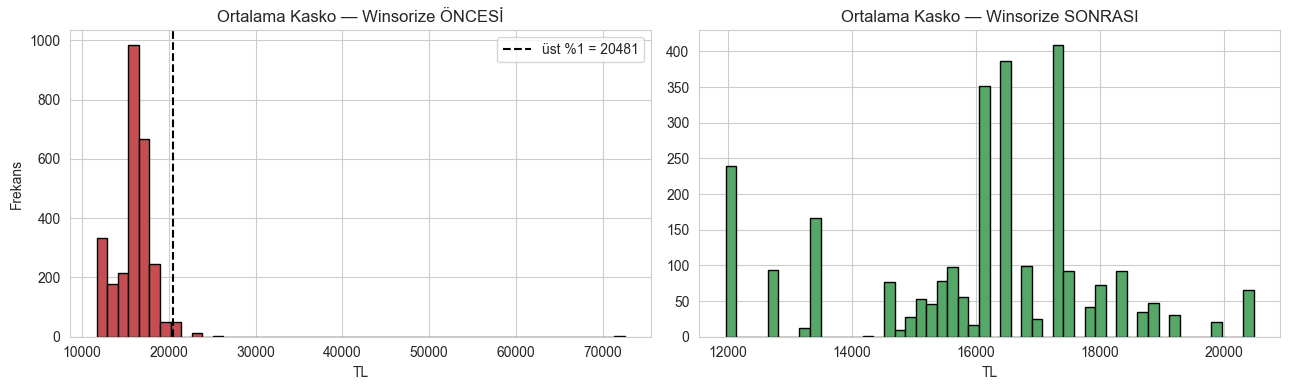


Skewness değişimi:
  Önce : 5.02
  Sonra: -0.47


In [41]:
# Karşılaştırma için orijinali yeniden yükle
X_train_orj = pd.read_csv('../data/X_train_step6.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
col = 'Ortalama Kasko'

axes[0].hist(X_train_orj[col].dropna(), bins=50, color='#c44e52', edgecolor='black')
axes[0].set_title(f'{col} — Winsorize ÖNCESİ')
axes[0].set_xlabel('TL')
axes[0].set_ylabel('Frekans')
axes[0].axvline(sinirlar[col][1], color='black', linestyle='--', label=f'üst %1 = {sinirlar[col][1]:.0f}')
axes[0].legend()

axes[1].hist(X_train[col].dropna(), bins=50, color='#55a868', edgecolor='black')
axes[1].set_title(f'{col} — Winsorize SONRASI')
axes[1].set_xlabel('TL')

plt.tight_layout()
plt.show()

print(f'\nSkewness değişimi:')
print(f'  Önce : {X_train_orj[col].skew():.2f}')
print(f'  Sonra: {X_train[col].skew():.2f}')

**Yorum:** Tek aykırı değer (72.520 TL Kona) kırpıldı. Skew dramatik düştü — dağılım artık çok daha simetriğe yakın.

## 7.4 Ara Kayıt

In [42]:
X_train.to_csv('../data/X_train_step7.csv', index=False)
X_test.to_csv('../data/X_test_step7.csv', index=False)
print('Ara kayıtlar:')
print('  data/X_train_step7.csv')
print('  data/X_test_step7.csv')

Ara kayıtlar:
  data/X_train_step7.csv
  data/X_test_step7.csv


---
# Adım 8 — Kategori Birleştirme + Encoding

**Bu adımda yapılacaklar:**
1. **Parça sayısı feature engineering**: `Lokal boyalı`, `Boyalı`, `Değişmiş` sütunlarından (parça listesi metni) sayım sütunları türet
2. **Drop**: `Ön Lastik`, `Boya-değişen` (özet, alt-sütunlardan zaten türettik), `Model` (target encoding sonrası)
3. **Target Encoding** (`Model`): X_train'den hedef ortalaması hesapla, X_test'e uygula (smoothing'li)
4. **One-Hot Encoding**: `Marka`, `Seri`, `Vites Tipi`, `Yakıt Tipi`, `Kasa Tipi`, `Renk`, `Çekiş`, `Kimden`

**Leakage koruması:** Tüm istatistikler X_train'den hesaplanır, X_test'e aynısı uygulanır.

## 8.1 Parça Sayısı Feature Engineering

`Lokal boyalı`, `Boyalı`, `Değişmiş` sütunlarında parça listesi metin var ("Sağ Ön Çamurluk Motor Kaputu" gibi). Anahtar parça kelimelerini sayarak 3 yeni numerik sütun türetiyoruz:

In [43]:
def parca_say(metin):
    """Parça anahtar kelimelerini say. '-' veya 'HAYIR' = 0."""
    if pd.isna(metin):
        return 0
    s = str(metin).strip()
    if s in ('-', 'HAYIR', ''):
        return 0
    parcalar = ['Çamurluk', 'Kaput', 'Kapı', 'Tavan', 'Tampon']
    return sum(s.count(p) for p in parcalar)

for d in (X_train, X_test):
    d['lokal_boyali_sayisi']  = d['Lokal boyalı'].apply(parca_say)
    d['boyali_sayisi']        = d['Boyalı'].apply(parca_say)
    d['degismis_sayisi']      = d['Değişmiş'].apply(parca_say)

print('Yeni parça sayısı sütunları (X_train özeti):\n')
print(X_train[['lokal_boyali_sayisi', 'boyali_sayisi', 'degismis_sayisi']].describe().round(2).to_string())

Yeni parça sayısı sütunları (X_train özeti):

       lokal_boyali_sayisi  boyali_sayisi  degismis_sayisi
count              2739.00        2739.00          2739.00
mean                  0.31           0.83             0.25
std                   0.82           1.74             0.62
min                   0.00           0.00             0.00
25%                   0.00           0.00             0.00
50%                   0.00           0.00             0.00
75%                   0.00           1.00             0.00
max                  13.00          13.00             5.00


**Yorum:** Parça sayıları artık numerik. Çoğu araç hasar/değişim yok (medyan 0), ama üst kuyrukta hasarlı araçlar görülecek — fiyat segmenti için önemli sinyal.

## 8.2 Artık Gereksiz Olan Sütunları At

- `Lokal boyalı`, `Boyalı`, `Değişmiş` → sayım sütunlarına çevirdik
- `Boya-değişen` → özet metin, alt-sütunlardan türetilebilir
- `Ön Lastik` → kullanıcı kararı: drop (lastik bilgisi indirek)

In [44]:
atilacaklar = ['Lokal boyalı', 'Boyalı', 'Değişmiş', 'Boya-değişen', 'Ön Lastik']
X_train = X_train.drop(columns=atilacaklar, errors='ignore')
X_test  = X_test.drop(columns=atilacaklar, errors='ignore')
print(f'Atılan: {atilacaklar}')
print(f'X_train şekli: {X_train.shape}')
print(f'X_test  şekli: {X_test.shape}')

Atılan: ['Lokal boyalı', 'Boyalı', 'Değişmiş', 'Boya-değişen', 'Ön Lastik']
X_train şekli: (2739, 36)
X_test  şekli: (685, 36)


## 8.3 Target Encoding — `Model`

`Model` sütunu 1000+ kardinaliteli; OHE imkansız (1000 yeni sütun). Target encoding kullanıyoruz: her modelin **X_train'deki fiyat sınıfı ortalaması**.

**Smoothing'li formül** (rare model'lerin overfit olmaması için):
$$\text{encoded} = \frac{n \cdot \text{group\_mean} + m \cdot \text{global\_mean}}{n + m}$$

- `n` = X_train'de o modelin örnek sayısı
- `m` = smoothing katsayısı (10 — varsayılan)
- `group_mean` = o modelin sınıf ortalaması
- `global_mean` = tüm X_train'in sınıf ortalaması

**Sınıf ordinal kodlama:** Ekonomik=0, Orta=1, Yüksek=2, Premium=3 (doğal sıralı).

In [45]:
# Hedefi ordinal sayıya çevir
y_mapping = {'Ekonomik': 0, 'Orta': 1, 'Yüksek': 2, 'Premium': 3}
y_train_num = y_train.map(y_mapping)

# Train'den lookup hazırla
smoothing = 10
global_mean = y_train_num.mean()

df_te = X_train[['Model']].copy()
df_te['y'] = y_train_num.values
agg = df_te.groupby('Model')['y'].agg(['mean', 'count'])
agg['smoothed'] = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)
model_te = agg['smoothed'].to_dict()

print(f'Toplam model sayısı (X_train): {len(model_te)}')
print(f'Global mean (Fiyat_Sinifi ordinal): {global_mean:.3f}')
print(f'\nÖrnek encoding (5 model):')
for k, v in list(model_te.items())[:5]:
    print(f'  {repr(k)[:50]:<52} → {v:.3f}')

Toplam model sayısı (X_train): 148
Global mean (Fiyat_Sinifi ordinal): 1.497

Örnek encoding (5 model):
  '10 DIG-T N-Sport'                                   → 1.543
  '10 DIG-T Platinum'                                  → 1.804
  '10 DIG-T Tekna'                                     → 1.541
  '10 T-GDI Elite'                                     → 1.820
  '10 T-GDI Jump'                                      → 1.332


In [46]:
# Train'e ve test'e uygula. Bilinmeyen model (test'te) → global_mean
X_train['Model_TE'] = X_train['Model'].map(model_te).fillna(global_mean)
X_test['Model_TE']  = X_test['Model'].map(model_te).fillna(global_mean)

# Bilinmeyen kaç adet?
n_bilinmeyen_test = X_test['Model'].apply(lambda m: m not in model_te).sum()
print(f'X_test\'te X_train\'de olmayan model sayısı: {n_bilinmeyen_test} (global_mean ile dolduruldu)')

# Orijinal Model sütununu at
X_train = X_train.drop(columns=['Model'])
X_test  = X_test.drop(columns=['Model'])
print(f'\nX_train şekli: {X_train.shape}')
print(f'Model_TE özeti (train):\n{X_train["Model_TE"].describe().round(3).to_string()}')

X_test'te X_train'de olmayan model sayısı: 6 (global_mean ile dolduruldu)

X_train şekli: (2739, 36)
Model_TE özeti (train):
count    2739.000
mean        1.540
std         0.764
min         0.272
25%         0.955
50%         1.477
75%         2.048
max         2.816


## 8.4 One-Hot Encoding — Düşük Kardinaliteli Kategorikler

`Marka` (2), `Seri` (~30), `Vites Tipi` (3), `Yakıt Tipi` (5), `Kasa Tipi` (4), `Renk` (4), `Çekiş` (4), `Kimden` (2). Toplam ~50 yeni dummy sütun.

**Train ve test sütun hizalaması:** test'te train'de olmayan kategori varsa o sütun eklenmez; train'de olup test'te olmayan kategori için 0'larla dolu sütun eklenir (`reindex`).

In [47]:
# Label-encoded float kategorikleri int'e çevir (OHE sütun isimleri temiz olsun)
label_kategorikler = ['Vites Tipi', 'Yakıt Tipi', 'Kasa Tipi', 'Renk', 'Çekiş', 'Kimden']
for d in (X_train, X_test):
    for c in label_kategorikler:
        d[c] = d[c].astype(int).astype(str)

# OHE'lenecek sütunlar
ohe_sutunlar = ['Marka', 'Seri'] + label_kategorikler

# get_dummies — int dtype 0/1 sütun üretir
X_train_enc = pd.get_dummies(X_train, columns=ohe_sutunlar, dtype=int)
X_test_enc  = pd.get_dummies(X_test,  columns=ohe_sutunlar, dtype=int)

# Test'i train'in sütun listesine hizala
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'OHE sonrası X_train: {X_train_enc.shape}')
print(f'OHE sonrası X_test : {X_test_enc.shape}')
print(f'\nÖrnek yeni sütunlar:')
yeni_sutunlar = [c for c in X_train_enc.columns if any(c.startswith(p+'_') for p in ohe_sutunlar)]
for c in yeni_sutunlar[:10]:
    print(f'  {c}')
print(f'  ... toplam {len(yeni_sutunlar)} OHE sütunu')

OHE sonrası X_train: (2739, 70)
OHE sonrası X_test : (685, 70)

Örnek yeni sütunlar:
  Marka_Hyundai
  Marka_Nissan
  Seri_Bayon
  Seri_Country
  Seri_Ioniq 5
  Seri_Juke
  Seri_Kona
  Seri_Navara
  Seri_Pathfinder
  Seri_Pick Up
  ... toplam 42 OHE sütunu


In [48]:
# Değişkenleri güncelle — bundan sonra X_train ve X_test encoded versiyonlar
X_train = X_train_enc
X_test  = X_test_enc

# Doğrulama: tüm sütun tipleri sayısal mı?
object_kalan = X_train.select_dtypes(include='object').columns.tolist()
if object_kalan:
    print(f'⚠ Hâlâ object sütun var: {object_kalan}')
else:
    print('✓ Tüm sütunlar sayısal — modellemeye uygun.')
print(f'\nX_train final boyut: {X_train.shape}')
print(f'X_test  final boyut: {X_test.shape}')

✓ Tüm sütunlar sayısal — modellemeye uygun.

X_train final boyut: (2739, 70)
X_test  final boyut: (685, 70)


## 8.5 Ara Kayıt

In [49]:
X_train.to_csv('../data/X_train_step8.csv', index=False)
X_test.to_csv('../data/X_test_step8.csv', index=False)
print('Ara kayıtlar:')
print('  data/X_train_step8.csv')
print('  data/X_test_step8.csv')

Ara kayıtlar:
  data/X_train_step8.csv
  data/X_test_step8.csv


## 8.6 Ek Feature Engineering — Türev Özellikler

Mevcut sütunlardan **istatistik kullanmadan** 4 yeni anlamlı özellik türetiyoruz. Hepsi deterministic, train ve test'e aynı formülle uygulanır.

| Yeni özellik | Formül | Niye işe yarar |
|---|---|---|
| `arac_yasi` | `2026 - Yıl` | Yaş fiyat segmenti için en güçlü sinyallerden biri |
| `km_per_yas` | `Kilometre / arac_yasi` | Yıllık km — bakımlı/yoğun kullanım göstergesi |
| `power_per_cc` | `Motor Gücü / Motor Hacmi × 1000` | Motor verimliliği (HP/L) — performans modelleri |
| `toplam_hasarli_parca` | `lokal_boyali + boyali + degismis` | Toplam hasar göstergesi |

In [50]:
REFERANS_YIL = 2026

for d in (X_train, X_test):
    # 1. Araç yaşı (en az 1 — 2026 modelin yaşı 0 olmasın)
    d['arac_yasi'] = (REFERANS_YIL - d['Yıl']).clip(lower=1)

    # 2. Yıllık ortalama km
    d['km_per_yas'] = d['Kilometre'] / d['arac_yasi']

    # 3. Motor verimliliği — HP / Litre (Motor Hacmi cc cinsinden)
    d['power_per_cc'] = (d['Motor Gücü'] / d['Motor Hacmi']) * 1000

    # 4. Toplam hasarlı parça
    d['toplam_hasarli_parca'] = (d['lokal_boyali_sayisi']
                                  + d['boyali_sayisi']
                                  + d['degismis_sayisi'])

yeni_ozellikler = ['arac_yasi', 'km_per_yas', 'power_per_cc', 'toplam_hasarli_parca']
print('Yeni özellikler — X_train özeti:\n')
print(X_train[yeni_ozellikler].describe().round(2).to_string())

Yeni özellikler — X_train özeti:

       arac_yasi  km_per_yas  power_per_cc  toplam_hasarli_parca
count    2739.00     2739.00       2739.00               2739.00
mean        8.21    26152.76         88.93                  1.38
std         5.17    36598.28         18.66                  2.14
min         1.00        0.38         30.91                  0.00
25%         4.00     7000.00         75.29                  0.00
50%         8.00    14625.00         84.85                  0.00
75%        11.00    28666.67         95.83                  2.00
max        30.00   400000.00        382.78                 13.00


**Yorum:**
- `arac_yasi` 1-30 arası tipik dağılım
- `km_per_yas` araçların yıllık km ortalaması (bakımlı=düşük, taksi/ticari=yüksek)
- `power_per_cc` 60-100 HP/L tipik aralık (turbo benzin > dizel > naturally aspirated)
- `toplam_hasarli_parca` 0-13 arası, çoğu sıfır (orijinal araçlar)

## 8.7 Final Ara Kayıt (4 yeni özellikle birlikte)

In [51]:
X_train.to_csv('../data/X_train_step8.csv', index=False)
X_test.to_csv('../data/X_test_step8.csv', index=False)
print(f'X_train final: {X_train.shape}')
print(f'X_test  final: {X_test.shape}')
print('\nKayıt: data/X_train_step8.csv, X_test_step8.csv (4 yeni FE özelliğiyle güncellendi)')

X_train final: (2739, 74)
X_test  final: (685, 74)

Kayıt: data/X_train_step8.csv, X_test_step8.csv (4 yeni FE özelliğiyle güncellendi)


---
# Adım 9 — Scaling (RobustScaler)

**Amaç:** Numerik özellikleri **aynı ölçeğe** getirmek. Yıl (~2020), Kilometre (~150.000) ve Motor Gücü (~130) çok farklı büyüklükte; uzaklık-tabanlı algoritmalar (k-NN, K-Means, LR) büyük sayıların etkisinde kalır.

**Niçin RobustScaler?**
- Medyan ve IQR (Q3-Q1) kullanır → aykırı değerlerden etkilenmez
- StandardScaler'a göre Kasko/Motor Gücü gibi az aykırılı sütunlarda daha sağlam

**Önemli:** Sadece **numerik** sütunlara uygulanır. **OHE sütunları (0/1) DOKUNULMAZ** — onlar zaten ölçek-bağımsız.

**Leakage:** Scaler `fit` sadece X_train'de yapılır, `transform` her ikisine de aynı parametrelerle uygulanır.

## 9.1 Numerik vs OHE Sütunları Ayır

In [52]:
# OHE sütunlarını prefix'e göre tespit et
ohe_prefixleri = ['Marka_', 'Seri_', 'Vites Tipi_', 'Yakıt Tipi_',
                  'Kasa Tipi_', 'Renk_', 'Çekiş_', 'Kimden_']
ohe_sutunlari = [c for c in X_train.columns
                 if any(c.startswith(p) for p in ohe_prefixleri)]
numerik_sutunlari = [c for c in X_train.columns if c not in ohe_sutunlari]

print(f'Numerik sütun sayısı: {len(numerik_sutunlari)}')
print(f'OHE sütun sayısı    : {len(ohe_sutunlari)}')
print(f'Toplam              : {len(X_train.columns)}')
print(f'\nNumerik sütunlar (scaler uygulanacak):')
for c in numerik_sutunlari:
    print(f'  {c}')

Numerik sütun sayısı: 32
OHE sütun sayısı    : 42
Toplam              : 74

Numerik sütunlar (scaler uygulanacak):
  Yıl
  Kilometre
  Motor Hacmi
  Motor Gücü
  Ort Yakıt Tüketimi
  Yakıt Deposu
  Ortalama Kasko
  Ortalama Trafik Sigortası
  Silindir Sayısı
  Tork
  Maksimum Güç
  Minimum Güç
  Hızlanma (0-100)
  Maksimum Hız
  Ortalama Yakıt Tüketimi
  Şehir İçi Yakıt Tüketimi
  Şehir Dışı Yakıt Tüketimi
  Uzunluk
  Genişlik
  Yükseklik
  Boş Ağırlığı
  Koltuk Sayısı
  Bagaj Hacmi
  orjinal_parca_sayisi
  lokal_boyali_sayisi
  boyali_sayisi
  degismis_sayisi
  Model_TE
  arac_yasi
  km_per_yas
  power_per_cc
  toplam_hasarli_parca


## 9.2 RobustScaler Fit + Transform

In [53]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X_train[numerik_sutunlari])

# Transform — train ve test'e aynı parametrelerle
X_train[numerik_sutunlari] = scaler.transform(X_train[numerik_sutunlari])
X_test[numerik_sutunlari]  = scaler.transform(X_test[numerik_sutunlari])

print('Scaler parametreleri (X_train\'den):')
param = pd.DataFrame({
    'medyan (center)': scaler.center_,
    'IQR (scale)'    : scaler.scale_
}, index=numerik_sutunlari)
print(param.round(2).to_string())

Scaler parametreleri (X_train'den):
                           medyan (center)  IQR (scale)
Yıl                                2018.00         7.00
Kilometre                        108000.00    119000.00
Motor Hacmi                        1500.00       137.00
Motor Gücü                          135.00        25.00
Ort Yakıt Tüketimi                    5.80         1.50
Yakıt Deposu                         55.00         4.00
Ortalama Kasko                    16546.00      2079.00
Ortalama Trafik Sigortası         11650.00       449.00
Silindir Sayısı                       4.00         1.00
Tork                                260.00       120.00
Maksimum Güç                       4000.00      1500.00
Minimum Güç                        2000.00      1250.00
Hızlanma (0-100)                     11.60         0.80
Maksimum Hız                        180.00         6.00
Ortalama Yakıt Tüketimi               5.80         1.50
Şehir İçi Yakıt Tüketimi              6.70         3.00
Şehir Dışı Y

## 9.3 Doğrulama — Ölçek kontrolü

In [54]:
print('Scaling sonrası numerik sütunların özet istatistikleri (X_train):\n')
ozet = X_train[numerik_sutunlari].describe().T[['mean', '50%', 'std', 'min', 'max']].round(2)
ozet.columns = ['mean', 'median', 'std', 'min', 'max']
print(ozet.to_string())

Scaling sonrası numerik sütunların özet istatistikleri (X_train):

                           mean  median   std    min    max
Yıl                       -0.03     0.0  0.74  -3.14   1.00
Kilometre                  0.13     0.0  0.74  -0.91   4.22
Motor Hacmi                0.24     0.0  1.95  -3.66  12.96
Motor Gücü                -0.03     0.0  1.09  -2.24  18.96
Ort Yakıt Tüketimi         0.10     0.0  0.79  -1.33   5.07
Yakıt Deposu               0.13     0.0  2.11  -4.25   6.25
Ortalama Kasko            -0.24     0.0  0.97  -2.21   1.89
Ortalama Trafik Sigortası  0.85     0.0  2.74  -3.23  15.96
Silindir Sayısı           -0.06     0.0  0.25  -1.00   2.00
Tork                       0.01     0.0  0.65  -1.23   4.00
Maksimum Güç               0.44     0.0  0.61  -0.27   1.53
Minimum Güç                0.33     0.0  0.82  -0.40   2.28
Hızlanma (0-100)          -0.08     0.0  1.74 -10.12   8.87
Maksimum Hız              -0.11     0.0  1.57  -7.50  13.33
Ortalama Yakıt Tüketimi    0.10  

**Yorum:** RobustScaler sonrası **medyan = 0**, IQR = 1 olur. Yani:
- Bir özelliğin değeri 0 → o değer ortanca civarında
- Değer 1 → Q3'e (üst çeyrek) yakın
- Değer -1 → Q1'e (alt çeyrek) yakın

Tüm numerikler şimdi karşılaştırılabilir ölçekte. OHE sütunları 0/1 olarak duruyor (etkilenmedi).

---
# Adım 10 — Final Kayıt

Modellemeye hazır 4 dosya kaydediyoruz. Bundan sonraki notebook'lar (`03_baseline.ipynb` vb.) bu dosyalardan okuyacak.

In [55]:
X_train.to_csv('../data/X_train_final.csv', index=False)
X_test.to_csv('../data/X_test_final.csv',   index=False)
y_train.to_csv('../data/y_train_final.csv', index=False)
y_test.to_csv('../data/y_test_final.csv',   index=False)

print('Final kayıtlar:')
print('  data/X_train_final.csv')
print('  data/X_test_final.csv')
print('  data/y_train_final.csv')
print('  data/y_test_final.csv')
print(f'\nFinal X_train şekli: {X_train.shape}')
print(f'Final X_test  şekli: {X_test.shape}')
print(f'\nSınıf dağılımı (train):')
print(y_train.value_counts(normalize=True).round(3).to_string())

Final kayıtlar:
  data/X_train_final.csv
  data/X_test_final.csv
  data/y_train_final.csv
  data/y_test_final.csv

Final X_train şekli: (2739, 74)
Final X_test  şekli: (685, 74)

Sınıf dağılımı (train):
Fiyat_Sinifi
Ekonomik    0.253
Yüksek      0.250
Premium     0.250
Orta        0.248


---
# 🎉 Preprocessing Tamamlandı

## Özet

| Adım | İşlem | Çıkış boyutu |
|---|---|---|
| 1 | %45+ eksik 3 sütun atıldı | 3424×40 |
| 2 | Eksiklik deseni analizi | 3424×40 |
| 3 | Numerik string parse + `_Başlık` drop | 3424×39 |
| 4 | Hedef oluştur (`Fiyat_Sinifi`) | 3424×40 |
| 5 | Train/test split (80/20, stratify) | Train: 2739×38, Test: 685×38 |
| 6 | Eksik doldurma (train-fit) | 0 eksik kalmadı |
| 7 | Winsorize (`Ortalama Kasko`) | 1 hatalı değer kırpıldı |
| 8 | Encoding + Feature Engineering | Train: 2739×74 |
| 9 | Scaling (RobustScaler) | Aynı boyut, ölçeklenmiş |
| 10 | Final kayıt | `*_final.csv` 4 dosya |

## Veri Sızıntısı (Leakage) Önleme

✓ Hedef (`Fiyat`, `Fiyat_Sinifi`) X'ten çıkarıldı  
✓ Eksik doldurma medyan/modu **sadece X_train'den** alındı  
✓ Winsorize sınırları **sadece X_train'den** hesaplandı  
✓ Target encoding (`Model_TE`) **sadece y_train'den** hesaplandı  
✓ Scaler **sadece X_train'e fit** edildi

## Sıradaki: `03_baseline.ipynb`

8 algoritmanın **varsayılan parametrelerle** baseline performansı ölçülecek:
1. k-NN
2. ID3 Karar Ağacı
3. C4.5
4. CART
5. Naive Bayes
6. Lojistik Regresyon
7. K-Means (destekli sınıflandırma)
8. Random Forest (özgünlük için)